--- Part 1: Building a Simple Feedforward Neural Network ---

Original FNN training data shape: (60000, 28, 28)
Original FNN test data shape: (10000, 28, 28)
Flattened & Normalized FNN training data shape: (60000, 784)
Flattened & Normalized FNN test data shape: (10000, 784)

--- FNN Model Summary ---



--- Training FNN Model ---

--- Evaluating FNN Model ---
FNN Test Loss: 0.3427
FNN Test Accuracy: 0.8751

--- FNN Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.88      0.84      1000
           1       0.98      0.97      0.98      1000
           2       0.79      0.78      0.78      1000
           3       0.89      0.88      0.89      1000
           4       0.71      0.86      0.78      1000
           5       0.96      0.98      0.97      1000
           6       0.75      0.53      0.62      1000
           7       0.95      0.94      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



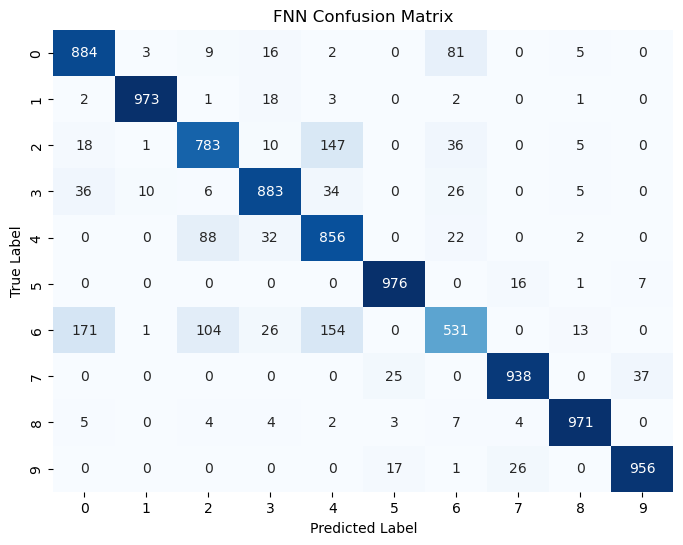


--- Part 2: Implementing a CNN ---

Original CNN training data shape: (60000, 28, 28)
Original CNN test data shape: (10000, 28, 28)
Reshaped & Normalized CNN training data shape: (60000, 28, 28, 1)
Reshaped & Normalized CNN test data shape: (10000, 28, 28, 1)

--- CNN Model Summary ---



--- Training CNN Model ---

--- Evaluating CNN Model ---
CNN Test Loss: 0.0236
CNN Test Accuracy: 0.9930


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist, mnist

tf.keras.utils.disable_interactive_logging()

# ==========================================
# Part 1: Feedforward Neural Network (FNN)
# ==========================================
print("--- Part 1: Building a Simple Feedforward Neural Network ---")

(x_train_fnn, y_train_fnn), (x_test_fnn, y_test_fnn) = fashion_mnist.load_data()
print(f"\nOriginal FNN training data shape: {x_train_fnn.shape}")
print(f"Original FNN test data shape: {x_test_fnn.shape}")

x_train_fnn_flat = x_train_fnn.reshape(-1, 28 * 28)
x_test_fnn_flat = x_test_fnn.reshape(-1, 28 * 28)

x_train_fnn_norm = x_train_fnn_flat / 255.0
x_test_fnn_norm = x_test_fnn_flat / 255.0
print(f"Flattened & Normalized FNN training data shape: {x_train_fnn_norm.shape}")
print(f"Flattened & Normalized FNN test data shape: {x_test_fnn_norm.shape}")

# Updated Sequential model using layers.Input to fix UserWarning
model_fnn = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model_fnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n--- FNN Model Summary ---")
model_fnn.summary()

print("\n--- Training FNN Model ---")
history_fnn = model_fnn.fit(
    x_train_fnn_norm,
    y_train_fnn,
    epochs=10,
    validation_split=0.1,
    verbose=1,
)

print("\n--- Evaluating FNN Model ---")
loss_fnn, accuracy_fnn = model_fnn.evaluate(
    x_test_fnn_norm, y_test_fnn, verbose=0
)
print(f"FNN Test Loss: {loss_fnn:.4f}")
print(f"FNN Test Accuracy: {accuracy_fnn:.4f}")

y_pred_fnn = np.argmax(model_fnn.predict(x_test_fnn_norm), axis=-1)
print("\n--- FNN Classification Report ---")
print(classification_report(y_test_fnn, y_pred_fnn))

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_fnn, y_pred_fnn),
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==========================================
# Part 2: Convolutional Neural Network (CNN)
# ==========================================
print("\n--- Part 2: Implementing a CNN ---")

(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = mnist.load_data()
print(f"\nOriginal CNN training data shape: {x_train_cnn.shape}")
print(f"Original CNN test data shape: {x_test_cnn.shape}")

x_train_cnn = x_train_cnn.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_cnn = x_test_cnn.reshape(-1, 28, 28, 1).astype("float32") / 255.0
print(f"Reshaped & Normalized CNN training data shape: {x_train_cnn.shape}")
print(f"Reshaped & Normalized CNN test data shape: {x_test_cnn.shape}")

model_cnn = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ]
)

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n--- CNN Model Summary ---")
model_cnn.summary()

print("\n--- Training CNN Model ---")
history_cnn = model_cnn.fit(
    x_train_cnn, y_train_cnn, epochs=5, validation_split=0.1, verbose=1
)

print("\n--- Evaluating CNN Model ---")
loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Test Loss: {loss_cnn:.4f}")
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")








In [ ]:
241501074